# Standard RL

In [2]:
import math
import random
import numpy as np
import gym
from gym import Env, spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import namedtuple, deque
from pythermalcomfort.models import pmv_ppd
from datetime import timedelta
from typing import Tuple
import pygame
import pandas as pd

pygame 2.5.2 (SDL 2.28.3, Python 3.11.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
class BuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        self.room_width, self.room_height = 800, 600

        self.action_space = spaces.Discrete(9)  # actions are temperature setpoints from 22°C to 30°C
        low = np.array([-10.0, 0.0, -3.0])  # [Outdoor Temp, Occupancy, Aggregated PMV]
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)

        self.time_step = 0
        self.max_steps = 48  # each step is 30 minutes, 48 steps in a day

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

        pygame.init()
        self.screen = pygame.display.set_mode((self.room_width, self.room_height))
        pygame.display.set_caption('Room Simulation')

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0  
        pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        aggregated_pmv = np.mean(pmv_values)
        return aggregated_pmv

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb  # mean radiant temperature
        rh = 50.0  # relative humidity
        v = 0.1  # air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, constant_setpoint=None):
        if constant_setpoint is not None:
            self.setpoint_temp = constant_setpoint
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER  # simplified power model

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        # NORMALIZING REWARD
        reward = reward / 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

In [4]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, 
                 eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-4):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state):
        # epsilon-greedy strategy
        sample = random.random()
        eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
            math.exp(-1. * self.steps_done / self.eps_decay)
        self.steps_done += 1
        if sample > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * self.tau + \
                                         target_net_state_dict[key] * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

In [5]:
def train(agent, env, constant_setpoint, episodes, target_update_frequency=10, render_interval=1):
    dqn_rewards = []
    baseline_rewards = []

    for e in range(episodes):
        # DQN training
        state = env.reset()
        state = torch.tensor([state], device=agent.device, dtype=torch.float32)
        total_dqn_reward = 0.0

        for time_step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, done, _ = env.step(action.item())
            reward = torch.tensor([reward], device=agent.device, dtype=torch.float32)

            next_state = torch.tensor([next_state], device=agent.device, dtype=torch.float32) if not done else None
            agent.memorize(state, action, next_state, reward)
            state = next_state
            total_dqn_reward += reward.item()
            agent.optimize_model()

            if time_step % render_interval == 0:
                env.render()  # render the room and users

            if done:
                break

        dqn_rewards.append(total_dqn_reward)

        if e % target_update_frequency == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        env.reset()
        total_baseline_reward = 0.0

        for time_step in range(env.max_steps):
            state, reward, done, _ = env.step(0, constant_setpoint=constant_setpoint)
            total_baseline_reward += reward

            if time_step % render_interval == 0:
                env.render()  # render the room 

            if done:
                break

        baseline_rewards.append(total_baseline_reward)

        print(f"Episode {e+1}/{episodes}, DQN Total Reward: {total_dqn_reward:.2f}, "
              f"Baseline Total Reward: {total_baseline_reward:.2f}")
    return dqn_rewards, baseline_rewards

def plot_rewards(dqn_rewards, baseline_rewards):
    import matplotlib.pyplot as plt
    plt.plot(dqn_rewards, label="DQN")
    plt.plot(baseline_rewards, label="Constant Setpoint", color="red")
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title('DQN vs Constant Setpoint: Total Reward per Episode')
    plt.legend()
    plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_25604\699041668.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  state = torch.tensor([state], device=agent.device, dtype=torch.float32)


Episode 1/365, DQN Total Reward: -1.03, Baseline Total Reward: -0.39
Episode 2/365, DQN Total Reward: -0.86, Baseline Total Reward: -0.39
Episode 3/365, DQN Total Reward: -0.92, Baseline Total Reward: -0.40
Episode 4/365, DQN Total Reward: -0.74, Baseline Total Reward: -0.40
Episode 5/365, DQN Total Reward: -0.95, Baseline Total Reward: -0.39
Episode 6/365, DQN Total Reward: -0.67, Baseline Total Reward: -0.40
Episode 7/365, DQN Total Reward: -0.98, Baseline Total Reward: -0.39
Episode 8/365, DQN Total Reward: -1.02, Baseline Total Reward: -0.37
Episode 9/365, DQN Total Reward: -0.81, Baseline Total Reward: -0.38
Episode 10/365, DQN Total Reward: -1.08, Baseline Total Reward: -0.38
Episode 11/365, DQN Total Reward: -0.99, Baseline Total Reward: -0.38
Episode 12/365, DQN Total Reward: -0.86, Baseline Total Reward: -0.41
Episode 13/365, DQN Total Reward: -1.13, Baseline Total Reward: -0.37
Episode 14/365, DQN Total Reward: -0.88, Baseline Total Reward: -0.41
Episode 15/365, DQN Total Rew

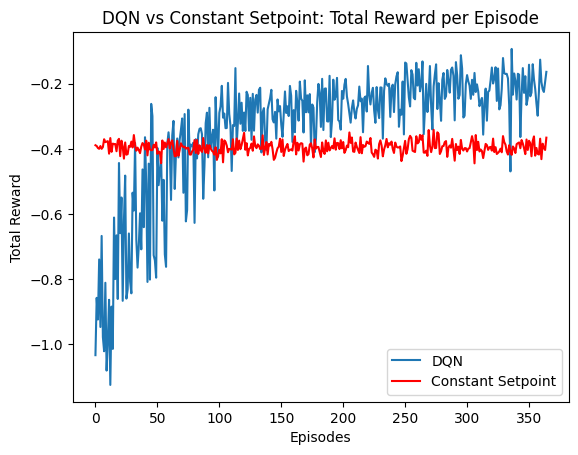

In [6]:
env = BuildingEnv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = DQNAgent(n_observations=env.observation_space.shape[0], n_actions=env.action_space.n, device=device)
episodes = 365
constant_setpoint_temp = 24.0  # can be changed.
dqn_rewards, baseline_rewards = train(agent, env, constant_setpoint_temp, episodes)
plot_rewards(dqn_rewards, baseline_rewards)

In [7]:
torch.save(agent.policy_net.state_dict(), 'dqn_model_no_adversary.pth')

# Simulation

In [5]:
import math
import random
import numpy as np
import gym
from gym import Env, spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import namedtuple, deque
from pythermalcomfort.models import pmv_ppd
from datetime import timedelta
from typing import Tuple
import pygame
import pandas as pd

In [ ]:
class BuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        
        self.simulation_width = 800  #simulation width
        self.simulation_height = 600  #ssimulation height
        self.left_panel_width = 340  
        self.padding = 30  # padding
        
        self.room_width = self.simulation_width + self.left_panel_width + (self.padding * 3)
        self.room_height = self.simulation_height + (self.padding * 2)

        self.action_space = spaces.Discrete(9)
        low = np.array([-10.0, 0.0, -3.0])
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)
        
        self.time_step = 0
        self.max_steps = 48
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0
        
        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }
        
        pygame.init()
        self.screen = pygame.display.set_mode((self.room_width, self.room_height))
        pygame.display.set_caption('Room Simulation')


    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0  
        pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        aggregated_pmv = np.mean(pmv_values)
        return aggregated_pmv

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb  # mean radiant temperature
        rh = 50.0  # relative humidity
        v = 0.1  # air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, constant_setpoint=None):
        if constant_setpoint is not None:
            self.setpoint_temp = constant_setpoint
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER  # simplified power model

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        # NORMALIZING REWARD
        reward = reward / 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state


    def capture_and_display_frame(self):
        import numpy as np
        from PIL import Image
        from IPython.display import display
        string_image = pygame.image.tostring(self.screen, 'RGB')
        temp_surf = Image.frombytes('RGB', (self.room_width, self.room_height), string_image)

        display(temp_surf)

    def render(self, capture_frame=False):
        COLORS = {
            'background': (248, 250, 252),
            'panel': (255, 255, 255),
            'text_primary': (30, 41, 59),
            'text_secondary': (100, 116, 139),
            'accent': (14, 165, 233),
            'border': (226, 232, 240),
            'pmv_cold': (56, 189, 248),
            'pmv_neutral': (34, 197, 94),
            'pmv_hot': (251, 113, 133)
        }
        
        if not hasattr(self, 'fonts_initialized'):
            pygame.font.init()
            try:
                self.title_font = pygame.font.SysFont('Segoe UI', 28, bold=True)
                self.heading_font = pygame.font.SysFont('Segoe UI', 20, bold=True)
                self.text_font = pygame.font.SysFont('Segoe UI', 16)
                self.small_font = pygame.font.SysFont('Segoe UI', 12)
            except:
                self.title_font = pygame.font.Font(None, 36)
                self.heading_font = pygame.font.Font(None, 28)
                self.text_font = pygame.font.Font(None, 24)
                self.small_font = pygame.font.Font(None, 20)
            self.fonts_initialized = True
        
        self.screen.fill(COLORS['background'])
        
        main_container = pygame.Rect(self.padding, self.padding, 
                                self.room_width - 2*self.padding, 
                                self.room_height - 2*self.padding)
        pygame.draw.rect(self.screen, COLORS['panel'], main_container, border_radius=8)
        
        # left
        info_x = self.padding * 2
        info_y = self.padding * 2
        
        # tilte
        title = self.title_font.render("Building Environment", True, COLORS['text_primary'])
        self.screen.blit(title, (info_x, info_y))
        info_y += 50
        
        sections = [
            ("Environmental", [
                f"Indoor Temp: {self.indoor_temp:.1f}°C",
                f"Outdoor Temp: {self.outdoor_temp:.1f}°C",
                f"Setpoint: {self.setpoint_temp:.1f}°C"
            ]),
            ("Occupancy", [
                f"Level: {self.occupancy_level*100:.0f}%",
                f"Users: {self.num_users}"
            ]),
            ("System", [
                f"HVAC Power: {self.hvac_power:.1f} kW",
                f"Time: {self.time_step//2:02d}:{(self.time_step%2)*30:02d}",
                f"Average PMV: {self.user_feedback:.2f}"
            ])
        ]
        
        for section_title, items in sections:
            header = self.heading_font.render(section_title, True, COLORS['text_primary'])
            self.screen.blit(header, (info_x, info_y))
            info_y += 30
            
            for item in items:
                text = self.text_font.render(item, True, COLORS['text_secondary'])
                self.screen.blit(text, (info_x, info_y))
                info_y += 25
            info_y += 15
        
        # Simulation Panel (exactly 800x600)
        sim_panel = pygame.Rect(self.left_panel_width + self.padding * 2, self.padding,
                            self.simulation_width, self.simulation_height)
        pygame.draw.rect(self.screen, COLORS['background'], sim_panel, border_radius=4)
        pygame.draw.rect(self.screen, COLORS['border'], sim_panel, 1, border_radius=4)
        
        # Draw users with grid-based grouping
        grid_size = 20
        user_grid = defaultdict(list)
        
        for user in self.users:
            grid_x = int((user['x'] % (self.simulation_width - 40)) / grid_size)
            grid_y = int((user['y'] % (self.simulation_height - 40)) / grid_size)
            user_grid[(grid_x, grid_y)].append(user)
        
        for (grid_x, grid_y), users_in_cell in user_grid.items():
            if not users_in_cell:
                continue
            
            x = sim_panel.left + 20 + grid_x * grid_size + grid_size/2
            y = sim_panel.top + 20 + grid_y * grid_size + grid_size/2
            
            pmv_values = [self.calculate_pmv(u['met'], u['clo']) for u in users_in_cell]
            avg_pmv = np.mean(pmv_values)
            
            if avg_pmv < -0.5:
                color = COLORS['pmv_cold']
            elif avg_pmv > 0.5:
                color = COLORS['pmv_hot']
            else:
                color = COLORS['pmv_neutral']
            
            dot_size = 3 + min(2, len(users_in_cell) // 10)
            pygame.draw.circle(self.screen, color, (int(x), int(y)), dot_size)
            
            if len(users_in_cell) > 1:
                count_text = self.small_font.render(str(len(users_in_cell)), 
                                                True, COLORS['text_secondary'])
                count_rect = count_text.get_rect(centerx=int(x), top=int(y) + 6)
                self.screen.blit(count_text, count_rect)
            else:
                pmv_text = self.small_font.render(f"{avg_pmv:.1f}", 
                                                True, COLORS['text_secondary'])
                pmv_rect = pmv_text.get_rect(centerx=int(x), top=int(y) + 6)
                self.screen.blit(pmv_text, pmv_rect)
        
        legend_y = self.room_height - self.padding - 20
        legend_items = [
            ("Cold (PMV < -0.5)", COLORS['pmv_cold']),
            ("Neutral", COLORS['pmv_neutral']),
            ("Hot (PMV > 0.5)", COLORS['pmv_hot'])
        ]
        
        legend_spacing = self.simulation_width // len(legend_items)
        for i, (text, color) in enumerate(legend_items):
            x_pos = sim_panel.left + (i + 0.5) * legend_spacing
            pygame.draw.circle(self.screen, color, (int(x_pos), legend_y), 4)
            legend_text = self.small_font.render(text, True, COLORS['text_secondary'])
            text_rect = legend_text.get_rect(centerx=int(x_pos), top=legend_y + 8)
            self.screen.blit(legend_text, text_rect)
        
        pygame.display.flip()
        
        if capture_frame:
            self.capture_and_display_frame()



Starting Building Environment Test Simulation

Episode 1/10
--------------------
Hour 6: Avg. PMV = 1.46, Avg. Power = 0.84 kW

Capturing frame at Episode 1, Step 14 (Time: 07:00)


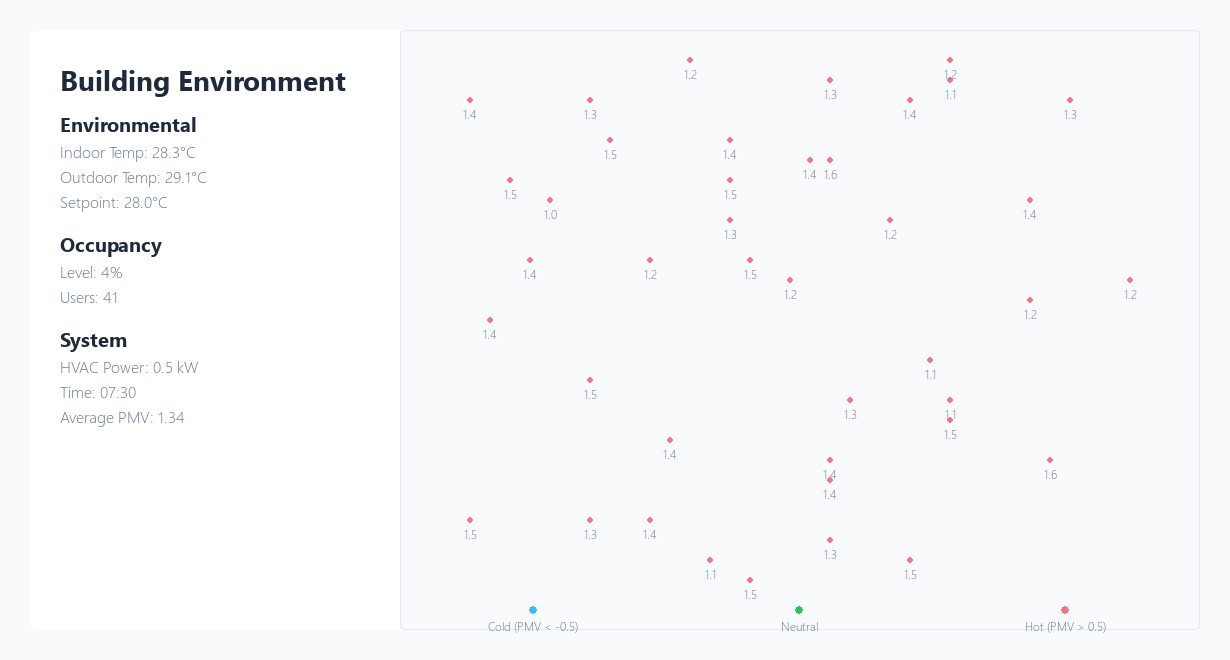

Hour 12: Avg. PMV = 1.11, Avg. Power = 0.63 kW
Hour 18: Avg. PMV = 0.86, Avg. Power = 0.76 kW
Hour 24: Avg. PMV = 1.32, Avg. Power = 0.36 kW

Episode 1 Summary:
Average Reward: -1.26
Average PMV: 1.19
Average Power Consumption: 0.65 kW
Average Indoor Temperature: 27.67°C

Episode 2/10
--------------------
Hour 6: Avg. PMV = 1.44, Avg. Power = 0.79 kW
Hour 12: Avg. PMV = 1.15, Avg. Power = 0.34 kW
Hour 18: Avg. PMV = 0.84, Avg. Power = 0.84 kW
Hour 24: Avg. PMV = 1.29, Avg. Power = 0.41 kW

Episode 2 Summary:
Average Reward: -1.38
Average PMV: 1.18
Average Power Consumption: 0.59 kW
Average Indoor Temperature: 27.66°C

Episode 3/10
--------------------
Hour 6: Avg. PMV = 1.45, Avg. Power = 0.80 kW
Hour 12: Avg. PMV = 1.13, Avg. Power = 0.32 kW
Hour 18: Avg. PMV = 0.86, Avg. Power = 0.76 kW
Hour 24: Avg. PMV = 1.30, Avg. Power = 0.33 kW

Episode 3 Summary:
Average Reward: -1.33
Average PMV: 1.18
Average Power Consumption: 0.55 kW
Average Indoor Temperature: 27.67°C

Episode 4/10
--------

KeyboardInterrupt: 

In [ ]:
def test_environment(episodes=10, steps_per_episode=48, capture_step=None):
    """
    Test the building environment and capture a frame at specified step
    """
    env = BuildingEnv()
    metrics = defaultdict(list)
    episode_rewards = []
    
    print("\nStarting Building Environment Test Simulation")
    print("============================================")
    
    for episode in range(episodes):
        state = env.reset()
        episode_reward = 0
        episode_metrics = defaultdict(list)
        
        print(f"\nEpisode {episode + 1}/{episodes}")
        print("--------------------")
        
        for step in range(steps_per_episode):
            if env.occupancy_level > 0.5:
                if env.outdoor_temp > 28:
                    action = 3
                elif env.outdoor_temp < 20:
                    action = 7
                else:
                    action = 5
            else:
                action = 6
            
            state, reward, done, _ = env.step(action)
            episode_reward += reward
            
            episode_metrics['indoor_temp'].append(env.indoor_temp)
            episode_metrics['outdoor_temp'].append(env.outdoor_temp)
            episode_metrics['hvac_power'].append(env.hvac_power)
            episode_metrics['occupancy'].append(env.occupancy_level)
            episode_metrics['pmv'].append(env.user_feedback)
            
            env.render()
            if capture_step is not None and episode == 0 and step == capture_step:
                print(f"\nCapturing frame at Episode 1, Step {step} (Time: {step//2:02d}:{(step%2)*30:02d})")
                env.capture_and_display_frame()
            
            pygame.time.wait(100) 
            
            if (step + 1) % 12 == 0:
                print(f"Hour {(step + 1)//2}: Avg. PMV = {np.mean(episode_metrics['pmv'][-12:]):.2f}, "
                      f"Avg. Power = {np.mean(episode_metrics['hvac_power'][-12:]):.2f} kW")
        
        for key, values in episode_metrics.items():
            metrics[key].append(values)
        episode_rewards.append(episode_reward)
        
        print(f"\nEpisode {episode + 1} Summary:")
        print(f"Average Reward: {episode_reward:.2f}")
        print(f"Average PMV: {np.mean(episode_metrics['pmv']):.2f}")
        print(f"Average Power Consumption: {np.mean(episode_metrics['hvac_power']):.2f} kW")
        print(f"Average Indoor Temperature: {np.mean(episode_metrics['indoor_temp']):.2f}°C")
    
    env.render(close=True)
    pygame.quit()
    return metrics, episode_rewards

if __name__ == "__main__":
    metrics, episode_rewards = test_environment(episodes=10, capture_step=14)  


# Comparison against Simulated Users

In [ ]:
import gym
from gym import spaces
import numpy as np
import pygame
import random
from pythermalcomfort.models import pmv_ppd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict, deque, namedtuple
import torch.optim as optim
import math

class BuildingEnv(gym.Env):
    def __init__(self, alpha=1, beta=1, EER=11, adversarial_ratio=0.4):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        self.adversarial_ratio = adversarial_ratio
        self.room_width, self.room_height = 800, 600
        
        self.prev_pmv = 0
        self.pmv_history = []  
        
        self.action_space = spaces.Discrete(9)
        low = np.array([-10.0, 0.0, -3.0])
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)
        
        self.time_step = 0
        self.max_steps = 48
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.is_adversarial = False
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0
        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': [],
            'is_adversarial': []
        }

        pygame.init()
        self.screen = pygame.display.set_mode((self.room_width, self.room_height))
        pygame.display.set_caption('Room Simulation')

    def calculate_adversarial_bias(self, current_pmv):
        pmv_direction = current_pmv - self.prev_pmv
        
        # Store PMV for trend analysis
        self.pmv_history.append(current_pmv)
        if len(self.pmv_history) > 5:
            self.pmv_history.pop(0)
        pmv_trend = np.mean(np.diff(self.pmv_history)) if len(self.pmv_history) > 1 else 0
        if current_pmv > 0:  #
            base_bias = -1.0 
        else:  
            base_bias = 1.0   
            
        if (pmv_direction * current_pmv) < 0:  
            base_bias *= 1.5
            
        trend_factor = -pmv_trend * 1.5  
        occupancy_scale = 0.5 + self.occupancy_level  
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        time_factor = 1.0
        if 9 <= time_of_day < 17: 
            time_factor = 1.5
        
        final_bias = (base_bias + trend_factor) * occupancy_scale * time_factor
        return np.clip(final_bias, -2.0, 2.0)

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:
            occupancy = np.random.uniform(0.2, 0.5)
        else:
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            self.prev_pmv = 0
            return 0
        
        self.is_adversarial = random.random() < self.adversarial_ratio
        pmv_values = []
        
        for user in self.users:
            met = user['met']
            clo = user['clo']
            if self.indoor_temp > 26:
                clo = max(0.5, clo - 0.1)
            elif self.indoor_temp < 20:
                clo = min(1.0, clo + 0.1)
            
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        
        base_pmv = np.mean(pmv_values)
        
        if self.is_adversarial:
            adversarial_bias = self.calculate_adversarial_bias(base_pmv)
            random_component = np.random.normal(0, 0.2)
            final_pmv = base_pmv + adversarial_bias + random_component
        else:
            final_pmv = base_pmv
            
        self.prev_pmv = base_pmv
        return np.clip(final_pmv, -3.0, 3.0)

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb
        rh = 50.0
        v = 0.1
        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, adversary_action=None):
        if adversary_action is not None:
            self.setpoint_temp = 22 + action
            base_influence = (adversary_action - 4) * 0.5
            
            if self.is_adversarial:
                if abs(self.user_feedback) > 1.0:
                    base_influence *= 1.2
                if self.occupancy_level > 0.7:
                    base_influence *= 1.5
            
            self.setpoint_temp += base_influence
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER
        
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        solar_gain = np.sin((time_of_day - 6) * np.pi / 12) * 0.05
        solar_gain = max(0, solar_gain)
        
        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * (0.12 if self.is_adversarial else 0.1)
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        
        self.indoor_temp += outdoor_influence + hvac_influence + solar_gain

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        reward = reward / 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)
        self.history['is_adversarial'].append(self.is_adversarial)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0
        self.is_adversarial = False
        self.prev_pmv = 0
        self.pmv_history = []

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

pygame 2.5.2 (SDL 2.28.3, Python 3.11.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
from collections import namedtuple
import torch 
import torch.nn as nn
import torch.nn.functional as F
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-3):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay 
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * self.tau + \
                                         target_net_state_dict[key] * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

Using device: cuda
Loading models...

Testing models with different adversarial ratios...

Testing with adversarial ratio: 0.0


C:\Users\adity\AppData\Local\Temp\ipykernel_17648\3986853232.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))
C:\Users\adity\AppDa

Testing Basic Model...
Run 1/3
Episode 1/150 - Total Reward: -0.14
Episode 2/150 - Total Reward: -0.09
Episode 3/150 - Total Reward: -0.19
Episode 4/150 - Total Reward: -0.11
Episode 5/150 - Total Reward: -0.10
Episode 6/150 - Total Reward: -0.09
Episode 7/150 - Total Reward: -0.14
Episode 8/150 - Total Reward: -0.15
Episode 9/150 - Total Reward: -0.14
Episode 10/150 - Total Reward: -0.10
Episode 11/150 - Total Reward: -0.13
Episode 12/150 - Total Reward: -0.12
Episode 13/150 - Total Reward: -0.12
Episode 14/150 - Total Reward: -0.09
Episode 15/150 - Total Reward: -0.09
Episode 16/150 - Total Reward: -0.13
Episode 17/150 - Total Reward: -0.16
Episode 18/150 - Total Reward: -0.11
Episode 19/150 - Total Reward: -0.14
Episode 20/150 - Total Reward: -0.14
Episode 21/150 - Total Reward: -0.11
Episode 22/150 - Total Reward: -0.12
Episode 23/150 - Total Reward: -0.07
Episode 24/150 - Total Reward: -0.13
Episode 25/150 - Total Reward: -0.13
Episode 26/150 - Total Reward: -0.14
Episode 27/150 -

Exception ignored in: <function Env.__del__ at 0x0000021950A9DF80>
Traceback (most recent call last):
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 202, in __del__
    self.close()
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 167, in close
    self.render(close=True)
TypeError: BuildingEnv.render() got an unexpected keyword argument 'close'


Episode 150/150 - Total Reward: -0.14

Testing with adversarial ratio: 0.5
Testing Basic Model...
Run 1/3
Episode 1/150 - Total Reward: -0.93
Episode 2/150 - Total Reward: -1.06
Episode 3/150 - Total Reward: -1.29
Episode 4/150 - Total Reward: -1.03
Episode 5/150 - Total Reward: -0.96
Episode 6/150 - Total Reward: -0.71
Episode 7/150 - Total Reward: -0.90
Episode 8/150 - Total Reward: -1.65
Episode 9/150 - Total Reward: -1.14
Episode 10/150 - Total Reward: -1.14
Episode 11/150 - Total Reward: -1.12
Episode 12/150 - Total Reward: -1.43
Episode 13/150 - Total Reward: -0.93
Episode 14/150 - Total Reward: -1.41
Episode 15/150 - Total Reward: -1.67
Episode 16/150 - Total Reward: -0.77
Episode 17/150 - Total Reward: -1.26
Episode 18/150 - Total Reward: -0.94
Episode 19/150 - Total Reward: -1.25
Episode 20/150 - Total Reward: -0.27
Episode 21/150 - Total Reward: -0.72
Episode 22/150 - Total Reward: -1.67
Episode 23/150 - Total Reward: -1.05
Episode 24/150 - Total Reward: -1.38
Episode 25/150 

Exception ignored in: <function Env.__del__ at 0x0000021950A9DF80>
Traceback (most recent call last):
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 202, in __del__
    self.close()
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 167, in close
    self.render(close=True)
TypeError: BuildingEnv.render() got an unexpected keyword argument 'close'


Episode 150/150 - Total Reward: -1.00

Testing with adversarial ratio: 1.0
Testing Basic Model...
Run 1/3
Episode 1/150 - Total Reward: -2.29
Episode 2/150 - Total Reward: -2.17
Episode 3/150 - Total Reward: -2.10
Episode 4/150 - Total Reward: -2.10
Episode 5/150 - Total Reward: -2.14
Episode 6/150 - Total Reward: -2.00
Episode 7/150 - Total Reward: -2.12
Episode 8/150 - Total Reward: -2.21
Episode 9/150 - Total Reward: -2.20
Episode 10/150 - Total Reward: -2.15
Episode 11/150 - Total Reward: -2.12
Episode 12/150 - Total Reward: -2.09
Episode 13/150 - Total Reward: -2.24
Episode 14/150 - Total Reward: -2.24
Episode 15/150 - Total Reward: -2.15
Episode 16/150 - Total Reward: -2.04
Episode 17/150 - Total Reward: -2.18
Episode 18/150 - Total Reward: -2.20
Episode 19/150 - Total Reward: -2.06
Episode 20/150 - Total Reward: -2.24
Episode 21/150 - Total Reward: -2.19
Episode 22/150 - Total Reward: -2.20
Episode 23/150 - Total Reward: -2.26
Episode 24/150 - Total Reward: -2.22
Episode 25/150 

Exception ignored in: <function Env.__del__ at 0x0000021950A9DF80>
Traceback (most recent call last):
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 202, in __del__
    self.close()
  File "c:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\gym\core.py", line 167, in close
    self.render(close=True)
TypeError: BuildingEnv.render() got an unexpected keyword argument 'close'


Episode 150/150 - Total Reward: -1.72

=== Performance Statistics ===

Adversarial Ratio: 0.0
DQN Average Reward: -0.1192 ± 0.0019
RARL Average Reward: -0.1224 ± 0.0004
Improvement: -2.7%

Adversarial Ratio: 0.5
DQN Average Reward: -1.1708 ± 0.0149
RARL Average Reward: -1.1833 ± 0.0173
Improvement: -1.1%

Adversarial Ratio: 1.0
DQN Average Reward: -2.1502 ± 0.0079
RARL Average Reward: -1.8323 ± 0.0066
Improvement: 14.8%


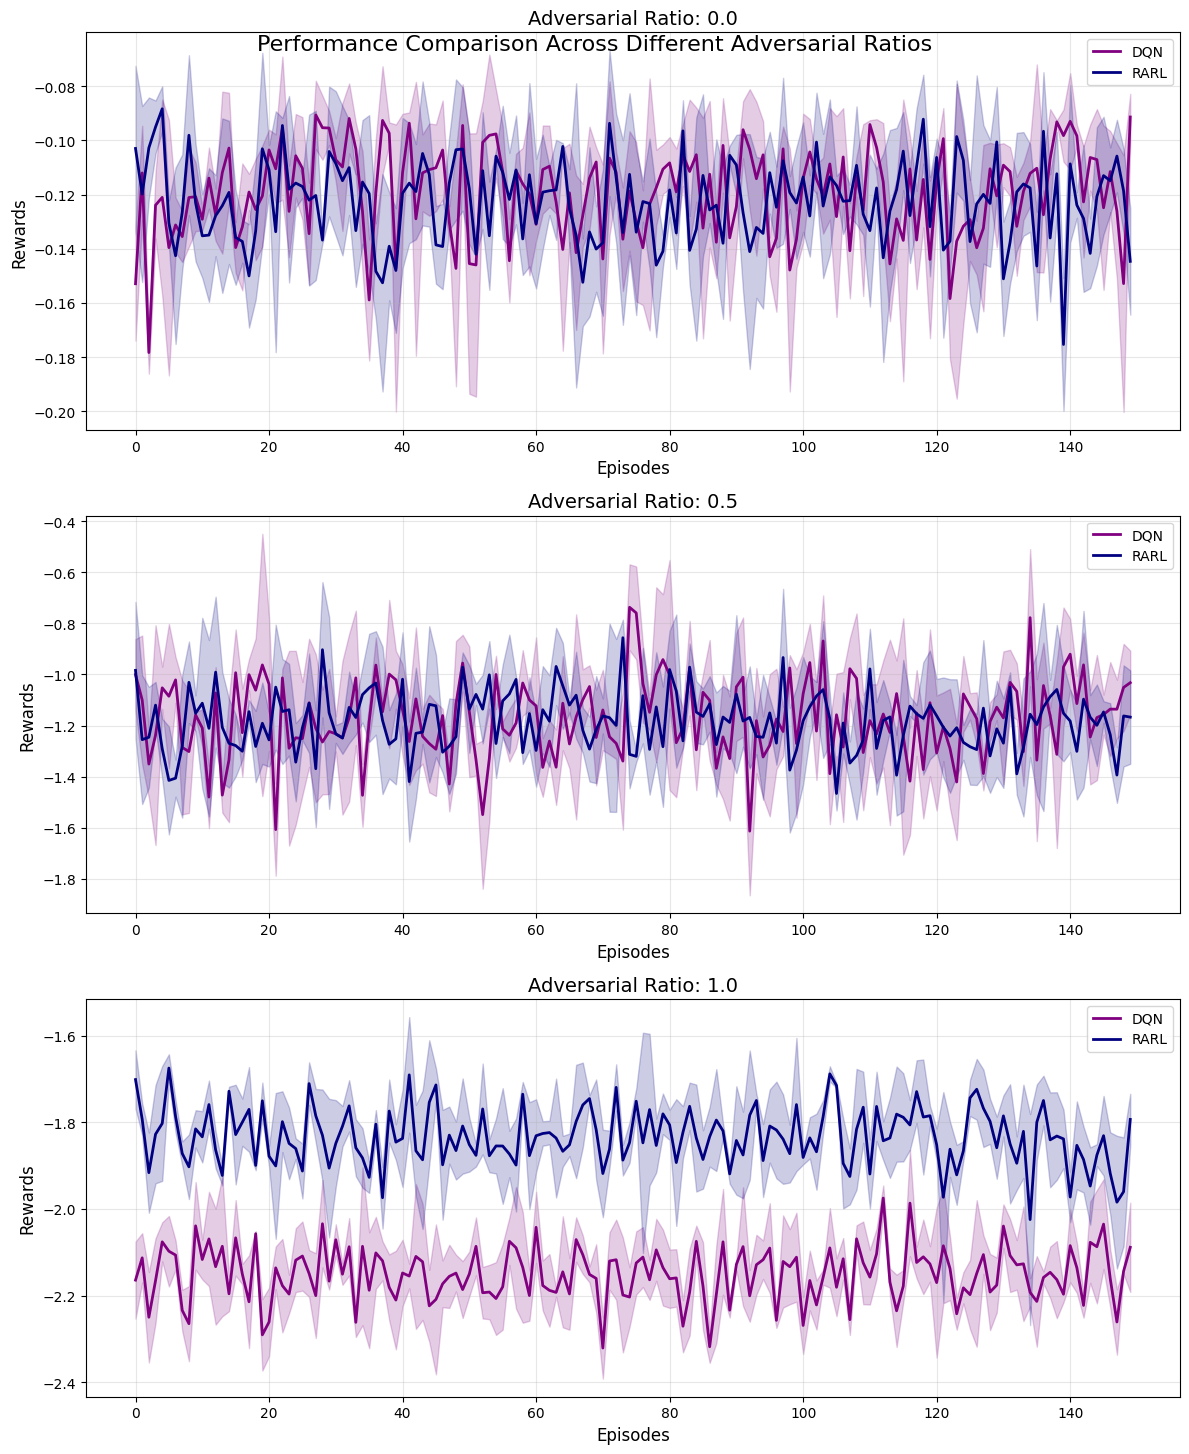

In [3]:
from collections import defaultdict
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_model(path, n_observations, n_actions, device):
    model = DQN(n_observations, n_actions).to(device)
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

def test_model(env, model, device, num_episodes=10):
    episode_stats = defaultdict(list)
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        episode_reward = 0
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                action = model(state_tensor).max(1).indices.item()
            next_state, reward, done, _ = env.step(action)
            episode_reward += reward
            episode_stats['rewards'].append(reward)
            episode_stats['indoor_temp'].append(env.indoor_temp)
            episode_stats['hvac_power'].append(env.hvac_power)
            episode_stats['pmv'].append(env.user_feedback)
            episode_stats['is_adversarial'].append(env.is_adversarial)
            episode_stats['actions'].append(action)
            episode_stats['setpoints'].append(22 + action)
            state = next_state
        episode_stats['episode_rewards'].append(episode_reward)
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward:.2f}")
    return episode_stats

def run_multiple_tests(env, model, device, num_runs=3, num_episodes=150):
    all_runs_rewards = []
    for run in range(num_runs):
        print(f"Run {run + 1}/{num_runs}")
        episode_stats = test_model(env, model, device, num_episodes)
        all_runs_rewards.append(episode_stats['episode_rewards'])
    return np.array(all_runs_rewards)

def plot_multi_ratio_rewards(results, ratios):
    fig, axes = plt.subplots(len(ratios), 1, figsize=(12, 5*len(ratios)))
    fig.suptitle('Performance Comparison Across Different Adversarial Ratios', fontsize=16, y=0.95)
    
    for idx, ratio in enumerate(ratios):
        ax = axes[idx] if len(ratios) > 1 else axes
        
        basic_rewards = results['basic'][ratio]
        rarl_rewards = results['rarl'][ratio]
        
        basic_mean = np.mean(basic_rewards, axis=0)
        basic_std = np.std(basic_rewards, axis=0)
        rarl_mean = np.mean(rarl_rewards, axis=0)
        rarl_std = np.std(rarl_rewards, axis=0)
        
        episodes = range(len(basic_mean))
        
        ax.plot(episodes, basic_mean, label='DQN', color='purple', linewidth=2)
        ax.fill_between(episodes, basic_mean - basic_std, basic_mean + basic_std, alpha=0.2, color='purple')
        
        ax.plot(episodes, rarl_mean, label='RARL', color='navy', linewidth=2)
        ax.fill_between(episodes, rarl_mean - rarl_std, rarl_mean + rarl_std, alpha=0.2, color='navy')
        
        ax.set_xlabel('Episodes', fontsize=12)
        ax.set_ylabel('Rewards', fontsize=12)
        ax.set_title(f'Adversarial Ratio: {ratio}', fontsize=14)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)
    
    plt.tight_layout()
    plt.show()

def print_ratio_statistics(results, ratios):
    print("\n=== Performance Statistics ===")
    for ratio in ratios:
        print(f"\nAdversarial Ratio: {ratio}")
        
        basic_avg = np.mean([np.mean(run) for run in results['basic'][ratio]])
        basic_std = np.std([np.mean(run) for run in results['basic'][ratio]])
        rarl_avg = np.mean([np.mean(run) for run in results['rarl'][ratio]])
        rarl_std = np.std([np.mean(run) for run in results['rarl'][ratio]])
        
        improvement = ((rarl_avg - basic_avg) / abs(basic_avg)) * 100
        
        print(f"DQN Average Reward: {basic_avg:.4f} ± {basic_std:.4f}")
        print(f"RARL Average Reward: {rarl_avg:.4f} ± {rarl_std:.4f}")
        print(f"Improvement: {improvement:.1f}%")

def test_multiple_ratios(env_class, basic_model, rarl_model, device, ratios=[0, 0.5, 1.0], runs_per_ratio=3, episodes=150):
    results = {
        'basic': {ratio: [] for ratio in ratios},
        'rarl': {ratio: [] for ratio in ratios}
    }
    
    for ratio in ratios:
        print(f"\nTesting with adversarial ratio: {ratio}")
        env = env_class(adversarial_ratio=ratio)
        
        print("Testing Basic Model...")
        basic_rewards = run_multiple_tests(env, basic_model, device, num_runs=runs_per_ratio, num_episodes=episodes)
        results['basic'][ratio] = basic_rewards
        
        print("Testing RARL Model...")
        rarl_rewards = run_multiple_tests(env, rarl_model, device, num_runs=runs_per_ratio, num_episodes=episodes)
        results['rarl'][ratio] = rarl_rewards
    
    return results

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    n_observations = 3
    n_actions = 9
    
    print("Loading models...")
    basic_model = load_model('dqn_model_no_adversary.pth', n_observations, n_actions, device)
    rarl_model = load_model('protagonist_model_with_energy.pth', n_observations, n_actions, device)
    
    ratios = [0.0, 0.5, 1.0]
    print("\nTesting models with different adversarial ratios...")
    results = test_multiple_ratios(BuildingEnv, basic_model, rarl_model, device, 
                                 ratios=ratios, runs_per_ratio=3, episodes=150)
    
    print_ratio_statistics(results, ratios)
    plot_multi_ratio_rewards(results, ratios)

if __name__ == "__main__":
    main()